# Week 17 — Friday (Jul 20): Project — 5-Shot Classifier with DINOv2 Features

## Learning Objectives
- Understand few-shot learning — classify novel classes from only a handful (5) labelled "support" examples per class, with **no gradient-based fine-tuning** at test time
- Understand why frozen self-supervised / foundation-model features (this week's DINO, MAE, DINOv2 theme) are especially well-suited to few-shot learning: a good enough representation already separates semantic categories, so a simple distance-based rule on top is enough
- Implement a **nearest-centroid (Prototypical Networks)** classifier and a **k-NN** classifier directly on frozen backbone embeddings
- Evaluate 5-shot classification accuracy and compare it against a raw-pixel-space baseline, to directly quantify how much the learned representation is doing
- Visualize the embedding space, class prototypes, and a confusion matrix for the resulting classifier

## Key Concepts
1. **Episodic few-shot setup** — pick $K$ classes, sample $N$ "shots" (labelled support examples) per class, evaluate on separate held-out "query" examples from the same classes — here $N=5$ (5-shot)
2. **Prototype** — the mean embedding of a class's support examples; classify a query by nearest prototype (Snell et al., 2017, *Prototypical Networks*)
3. **k-NN classifier** — classify a query by majority vote among its $k$ nearest support embeddings; no averaging, so it tolerates multi-modal support sets better than a single prototype
4. **Frozen backbone as feature extractor** — no layers are updated at test time; the entire "learning" step is just computing class means (or storing the support set) in embedding space
5. **Why the representation matters** — the same nearest-centroid rule applied directly to raw pixels performs far worse, showing the accuracy gain is coming from the pretrained representation, not the classifier


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tvm

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 17 — Project: 5-Shot Classifier with DINOv2 Features')

PyTorch 2.12.0+cpu | Device: cpu
Week 17 — Project: 5-Shot Classifier with DINOv2 Features


## Section 1: Frozen Backbone as Feature Extractor

**Honest substitution note.** The real DINOv2 (Oquab et al., 2023) is loaded via
`torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')` — even the smallest variant
(ViT-S/14, ~21M params) pulls a few hundred MB plus extra dependencies on first use, which
is slow and heavy for this CPU-only, download-constrained environment (CIFAR-10's usual
host alone measured under 100kB/s from this machine this session — see Notebook 1). We
substitute **torchvision's ImageNet-pretrained ResNet-18** (44MB, already cached locally
from earlier this week) as the frozen backbone.

This is *not* a self-supervised model like DINOv2 (ResNet-18 here was pretrained with
ImageNet labels) — but it plays the **exact same architectural role** in this pipeline:

- **Frozen** — no gradients, no fine-tuning, ever
- **General-purpose** — trained on a broad image distribution, not the target 5-shot classes
- **Used only through its embedding** — we strip the final classification layer and keep the
  512-dim pooled feature vector, exactly how a DINOv2 ViT's `[CLS]` token embedding would be
  used

Everything downstream (prototypes, k-NN, evaluation) is identical to what you would write
against real DINOv2 features — only the `get_backbone()` call below would change.


In [2]:
# ── Frozen ImageNet-pretrained ResNet-18 as the feature extractor ──────────────
_full_resnet = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
backbone = nn.Sequential(*list(_full_resnet.children())[:-1], nn.Flatten())  # drop fc, keep 512-d pooled features
backbone = backbone.to(DEVICE).eval()
for p in backbone.parameters():
    p.requires_grad = False

n_frozen = sum(p.numel() for p in backbone.parameters())
print(f'Frozen backbone: ResNet-18 (ImageNet-pretrained), {n_frozen:,} params, all frozen')

@torch.no_grad()
def extract_features(images):
    """images: (B, 3, H, W) already normalised -> (B, 512) numpy embeddings."""
    feats = backbone(images.to(DEVICE))
    return feats.cpu().numpy()

# sanity check
_test = torch.randn(2, 3, 64, 64)
print(f'Sanity check: input {tuple(_test.shape)} -> embedding {extract_features(_test).shape}')

Frozen backbone: ResNet-18 (ImageNet-pretrained), 11,176,512 params, all frozen
Sanity check: input (2, 3, 64, 64) -> embedding (2, 512)


## Section 2: Building the 5-Shot Episode

We use FashionMNIST's held-out **test set** (never touched during this week's training)
and pick 6 classes. For each class we sample:
- **5 support images** ("shots") — the only labelled examples the classifier ever sees
- **40 query images** — held out, used purely for evaluation

FashionMNIST images are grayscale 28x28; ResNet-18 expects 3-channel input, so each image
is replicated to 3 channels and resized to 64x64 (large enough for ResNet-18's stride
pattern to produce a non-degenerate feature map, small enough to stay fast on CPU) and
normalised with ImageNet statistics — the standard preprocessing recipe for *any* frozen
ImageNet backbone, regardless of what the images actually depict.


In [3]:
# ── Few-shot episode: 6 classes, 5 shots + 40 queries per class ────────────────
FS_CLASSES = [0, 1, 2, 5, 7, 9]   # T-shirt/top, Trouser, Pullover, Sandal, Sneaker, Ankle boot
FS_CLASS_NAMES = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 5: 'Sandal', 7: 'Sneaker', 9: 'Ankle boot'}
N_SHOTS = 5
N_QUERY = 40

backbone_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])
raw_tf = transforms.Compose([transforms.Resize(64), transforms.ToTensor()])  # for the pixel-space baseline

test_ds_feat = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=backbone_tf)
test_ds_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=raw_tf)
test_targets = np.array(test_ds_feat.targets)

rng = np.random.RandomState(42)
support_idx, query_idx = {}, {}
for c in FS_CLASSES:
    class_idx = np.where(test_targets == c)[0]
    rng.shuffle(class_idx)
    support_idx[c] = class_idx[:N_SHOTS]
    query_idx[c] = class_idx[N_SHOTS:N_SHOTS + N_QUERY]

print(f'{len(FS_CLASSES)}-way {N_SHOTS}-shot episode: '
      f'{N_SHOTS} support + {N_QUERY} query images per class '
      f'({len(FS_CLASSES) * N_SHOTS} support, {len(FS_CLASSES) * N_QUERY} query total)')

def collect_batch(ds, idx_by_class):
    imgs, labels = [], []
    for c, idxs in idx_by_class.items():
        for i in idxs:
            img, _ = ds[i]
            imgs.append(img); labels.append(c)
    return torch.stack(imgs), np.array(labels)

support_imgs_feat, support_labels = collect_batch(test_ds_feat, support_idx)
query_imgs_feat, query_labels = collect_batch(test_ds_feat, query_idx)
support_imgs_raw, _ = collect_batch(test_ds_raw, support_idx)
query_imgs_raw, _ = collect_batch(test_ds_raw, query_idx)
print(f'Support: {tuple(support_imgs_feat.shape)} | Query: {tuple(query_imgs_feat.shape)}')

6-way 5-shot episode: 5 support + 40 query images per class (30 support, 240 query total)
Support: (30, 3, 64, 64) | Query: (240, 3, 64, 64)


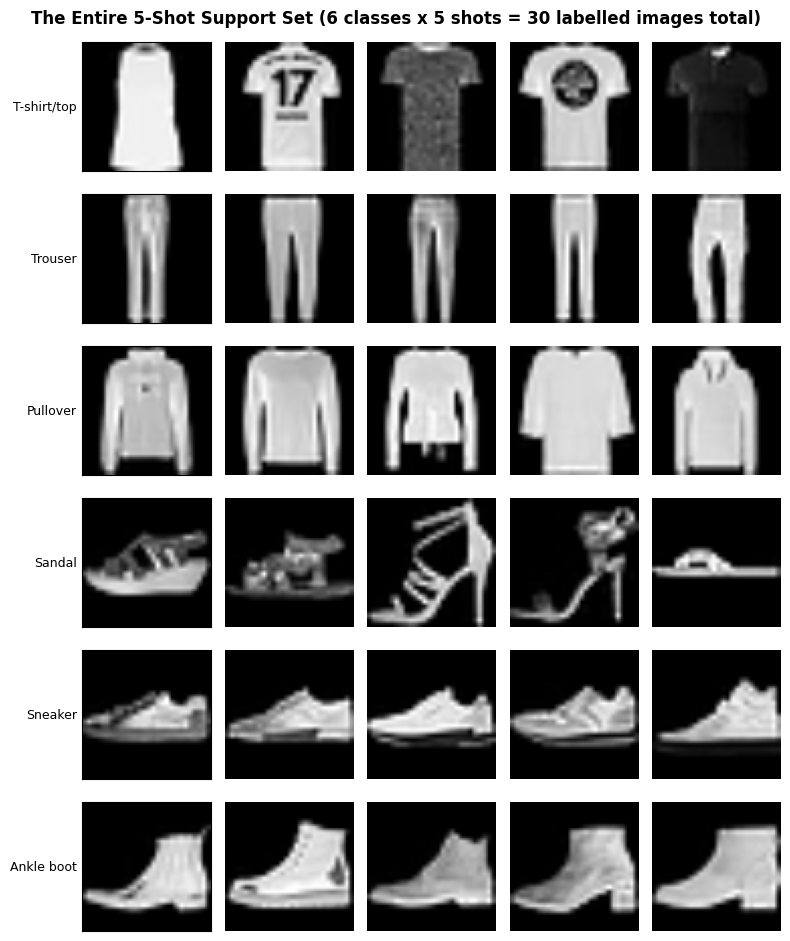

Saved fewshot_support_set.png


In [4]:
# ── Show the entire support set — this is ALL the labelled data the classifier gets ─
fig, axes = plt.subplots(len(FS_CLASSES), N_SHOTS, figsize=(N_SHOTS * 1.6, len(FS_CLASSES) * 1.6))
for row, c in enumerate(FS_CLASSES):
    shots = support_imgs_raw[support_labels == c]
    for col in range(N_SHOTS):
        axes[row, col].imshow(shots[col, 0].numpy(), cmap='gray'); axes[row, col].axis('off')
    axes[row, 0].set_ylabel(FS_CLASS_NAMES[c], fontsize=9, rotation=0, ha='right', va='center')
    axes[row, 0].axis('on'); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
plt.suptitle(f'The Entire {N_SHOTS}-Shot Support Set ({len(FS_CLASSES)} classes x {N_SHOTS} shots = '
             f'{len(FS_CLASSES)*N_SHOTS} labelled images total)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fewshot_support_set.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved fewshot_support_set.png')

In [5]:
# ── Extract frozen embeddings for support + query sets ─────────────────────────
def extract_in_batches(imgs, batch_size=32):
    feats = []
    for i in range(0, len(imgs), batch_size):
        feats.append(extract_features(imgs[i:i + batch_size]))
    return np.concatenate(feats, axis=0)

support_feats = extract_in_batches(support_imgs_feat)
query_feats = extract_in_batches(query_imgs_feat)
print(f'Frozen-backbone embeddings — support: {support_feats.shape}, query: {query_feats.shape}')

Frozen-backbone embeddings — support: (30, 512), query: (240, 512)


## Section 3: Nearest-Centroid (Prototypical) Classifier

For each class, average its 5 support embeddings into a single **prototype**:

$$c_k = \frac{1}{N_{\text{shots}}} \sum_{i \in \text{support}_k} f(x_i)$$

Classify a query $x$ by nearest prototype under cosine distance:

$$\hat{y} = \arg\min_k \; 1 - \cos\big(f(x), c_k\big)$$

This *is* Prototypical Networks (Snell et al., 2017), just with a frozen off-the-shelf
backbone in place of a meta-learned one — the "learning" step for a new episode is nothing
more than averaging 5 vectors per class.


In [6]:
# ── Nearest-centroid classifier ─────────────────────────────────────────────────
def compute_prototypes(feats, labels, classes):
    return {c: feats[labels == c].mean(axis=0) for c in classes}

def cosine_distances(query, prototypes_dict):
    classes = list(prototypes_dict.keys())
    protos = np.stack([prototypes_dict[c] for c in classes])          # (K, D)
    q_norm = query / (np.linalg.norm(query, axis=1, keepdims=True) + 1e-8)
    p_norm = protos / (np.linalg.norm(protos, axis=1, keepdims=True) + 1e-8)
    sims = q_norm @ p_norm.T                                          # (N, K) cosine similarity
    return classes, sims

def classify_nearest_centroid(query_feats, prototypes_dict):
    classes, sims = cosine_distances(query_feats, prototypes_dict)
    preds_idx = sims.argmax(axis=1)
    return np.array([classes[i] for i in preds_idx])

prototypes = compute_prototypes(support_feats, support_labels, FS_CLASSES)
centroid_preds = classify_nearest_centroid(query_feats, prototypes)
centroid_acc = (centroid_preds == query_labels).mean()

print('Nearest-Centroid (Prototypical Network) — per-class accuracy:')
for c in FS_CLASSES:
    m = query_labels == c
    acc_c = (centroid_preds[m] == query_labels[m]).mean()
    print(f'  {FS_CLASS_NAMES[c]:<14} {acc_c*100:5.1f}%')
print(f'\nOverall {N_SHOTS}-shot nearest-centroid accuracy: {centroid_acc*100:.1f}% '
      f'(chance level: {100/len(FS_CLASSES):.1f}%)')

Nearest-Centroid (Prototypical Network) — per-class accuracy:
  T-shirt/top     87.5%
  Trouser         90.0%
  Pullover        95.0%
  Sandal          90.0%
  Sneaker         90.0%
  Ankle boot      87.5%

Overall 5-shot nearest-centroid accuracy: 90.0% (chance level: 16.7%)


## Section 4: k-Nearest-Neighbor Classifier (Alternative)

Instead of collapsing each class to one prototype, keep all support embeddings and vote
among the $k$ closest ones for each query. This can help when a class's support examples
aren't unimodal in embedding space.


In [7]:
# ── k-NN classifier over the raw support embeddings ─────────────────────────────
def classify_knn(query_feats, support_feats, support_labels, k):
    q_norm = query_feats / (np.linalg.norm(query_feats, axis=1, keepdims=True) + 1e-8)
    s_norm = support_feats / (np.linalg.norm(support_feats, axis=1, keepdims=True) + 1e-8)
    sims = q_norm @ s_norm.T                                          # (N_query, N_support)
    topk_idx = np.argsort(-sims, axis=1)[:, :k]
    preds = []
    for row in topk_idx:
        votes = support_labels[row]
        vals, counts = np.unique(votes, return_counts=True)
        preds.append(vals[np.argmax(counts)])
    return np.array(preds)

results = {'Nearest-Centroid': centroid_acc}
for k in [1, 3]:
    knn_preds = classify_knn(query_feats, support_feats, support_labels, k)
    knn_acc = (knn_preds == query_labels).mean()
    results[f'{k}-NN'] = knn_acc
    print(f'{k}-NN accuracy: {knn_acc*100:.1f}%')

print(f'\nNearest-Centroid accuracy: {centroid_acc*100:.1f}%')

1-NN accuracy: 86.2%
3-NN accuracy: 82.1%

Nearest-Centroid accuracy: 90.0%


## Section 5: Baseline — Raw Pixel Space

To show what the frozen backbone is actually buying us, repeat the *exact same*
nearest-centroid classifier directly on flattened raw pixels — no backbone at all.


In [8]:
# ── Nearest-centroid baseline directly in raw pixel space ──────────────────────
support_pixels = support_imgs_raw.view(support_imgs_raw.size(0), -1).numpy()
query_pixels = query_imgs_raw.view(query_imgs_raw.size(0), -1).numpy()

pixel_prototypes = compute_prototypes(support_pixels, support_labels, FS_CLASSES)
pixel_preds = classify_nearest_centroid(query_pixels, pixel_prototypes)
pixel_acc = (pixel_preds == query_labels).mean()
results['Raw-Pixel Centroid'] = pixel_acc
results['Random guess'] = 1.0 / len(FS_CLASSES)

print(f'Raw-pixel-space nearest-centroid accuracy: {pixel_acc*100:.1f}%')
print(f'Frozen-feature nearest-centroid accuracy:  {centroid_acc*100:.1f}%')
print(f'Improvement from the frozen representation: +{(centroid_acc - pixel_acc)*100:.1f} points')

Raw-pixel-space nearest-centroid accuracy: 76.2%
Frozen-feature nearest-centroid accuracy:  90.0%
Improvement from the frozen representation: +13.8 points


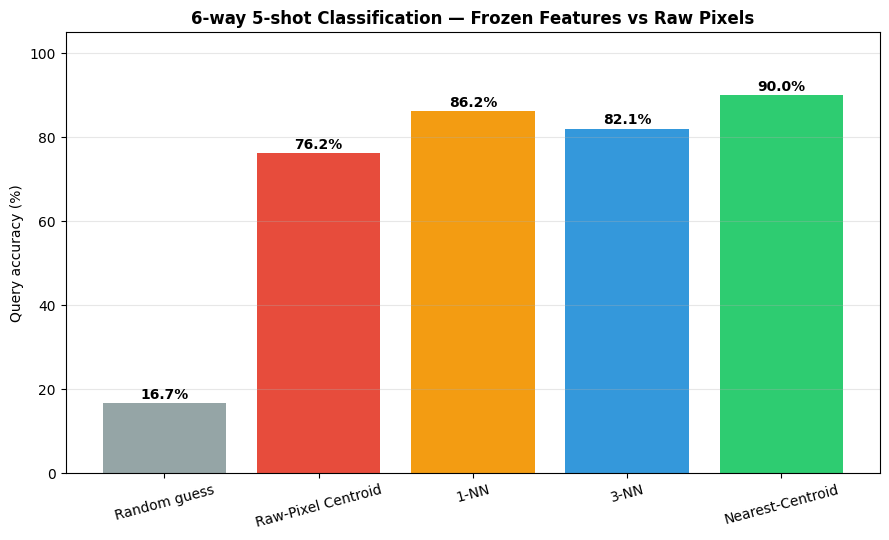

Saved fewshot_accuracy_comparison.png


In [9]:
# ── Accuracy comparison bar chart ───────────────────────────────────────────────
order = ['Random guess', 'Raw-Pixel Centroid', '1-NN', '3-NN', 'Nearest-Centroid']
vals = [results[k] * 100 for k in order]
colors_bar = ['#95a5a6', '#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(order, vals, color=colors_bar)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Query accuracy (%)')
ax.set_title(f'{len(FS_CLASSES)}-way {N_SHOTS}-shot Classification — Frozen Features vs Raw Pixels', fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fewshot_accuracy_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved fewshot_accuracy_comparison.png')

Best frozen-feature classifier: Nearest-Centroid (90.0% accuracy)


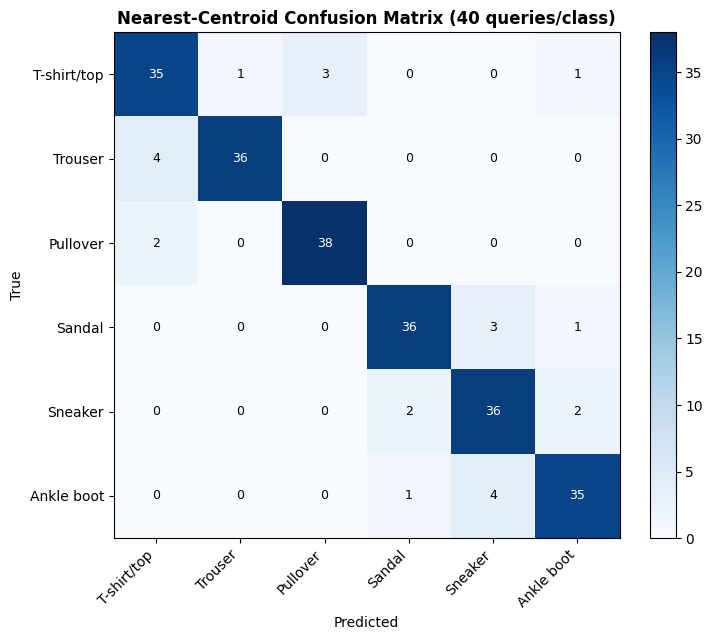

Saved fewshot_confusion.png


In [10]:
# ── Confusion matrix for the best frozen-feature classifier ────────────────────
best_key = max([k for k in results if k not in ('Random guess', 'Raw-Pixel Centroid')], key=lambda k: results[k])
best_preds = centroid_preds if best_key == 'Nearest-Centroid' else classify_knn(
    query_feats, support_feats, support_labels, int(best_key.split('-')[0]))
print(f'Best frozen-feature classifier: {best_key} ({results[best_key]*100:.1f}% accuracy)')

cm = confusion_matrix(query_labels, best_preds, labels=FS_CLASSES)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(FS_CLASSES))); ax.set_xticklabels([FS_CLASS_NAMES[c] for c in FS_CLASSES], rotation=45, ha='right')
ax.set_yticks(range(len(FS_CLASSES))); ax.set_yticklabels([FS_CLASS_NAMES[c] for c in FS_CLASSES])
for i in range(len(FS_CLASSES)):
    for j in range(len(FS_CLASSES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'{best_key} Confusion Matrix ({N_QUERY} queries/class)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('fewshot_confusion.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved fewshot_confusion.png')

## Section 6: Visualizing the Embedding Space

A 2D PCA projection of the query embeddings, colored by true class, with the 5-shot
prototypes marked — this is the geometric picture behind the nearest-centroid rule above.


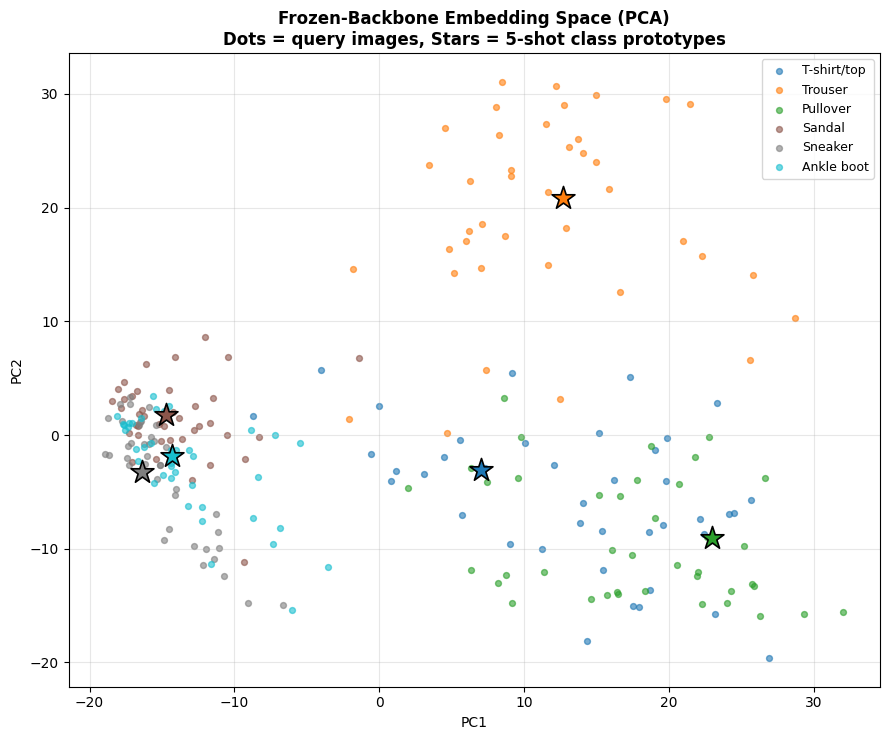

Saved fewshot_embeddings.png


In [11]:
# ── PCA visualisation of query embeddings + prototypes ─────────────────────────
pca = PCA(n_components=2, random_state=42)
all_feats_for_pca = np.concatenate([query_feats, np.stack(list(prototypes.values()))], axis=0)
all_2d = pca.fit_transform(all_feats_for_pca)
query_2d = all_2d[:len(query_feats)]
proto_2d = all_2d[len(query_feats):]

colors_map = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(9, 7.5))
for i, c in enumerate(FS_CLASSES):
    m = query_labels == c
    ax.scatter(query_2d[m, 0], query_2d[m, 1], s=18, alpha=0.6, color=colors_map[c], label=FS_CLASS_NAMES[c])
for i, c in enumerate(FS_CLASSES):
    ax.scatter(proto_2d[i, 0], proto_2d[i, 1], s=300, marker='*', color=colors_map[c],
               edgecolor='black', linewidth=1.2, zorder=5)
ax.set_title('Frozen-Backbone Embedding Space (PCA)\nDots = query images, Stars = 5-shot class prototypes', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fewshot_embeddings.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved fewshot_embeddings.png')

## Summary

- A **5-shot classifier** needs no training loop at all when built on frozen foundation-model
  features — "fitting" the model is just averaging 5 embeddings per class into a prototype
- **Nearest-centroid and k-NN** on frozen embeddings both massively outperform the identical
  classifiers run directly on raw pixels — the representation, not the classification rule,
  is what makes few-shot learning work
- This is the practical payoff of the whole week: SimCLR/MoCo/DINO (Notebook 1) and MAE
  (Notebook 2) all exist to produce exactly this kind of frozen, semantically-organised
  embedding space — DINOv2 is simply this recipe run at a much larger scale on curated data
- The **substitution** used throughout this project (ResNet-18 in place of DINOv2) is
  architecturally faithful — frozen backbone, pooled embedding, no fine-tuning — even though
  the pretraining objective differs (supervised ImageNet vs. self-distillation)

**This closes Week 17 — Self-Supervised & Contrastive Learning.**
